Device: cuda:0

Running benchmark...

  Plants   Nodes    GPU fps    ms/frame
Module __main__ d682134 load on device 'cuda:0' took 225.58 ms  (compiled)
       1      32       37.2       26.87
       5     160        9.1      109.59
      10     320        4.7      214.85
      25     800        1.8      549.69
      50    1600        0.9     1101.94

Rendering 10-plant field...


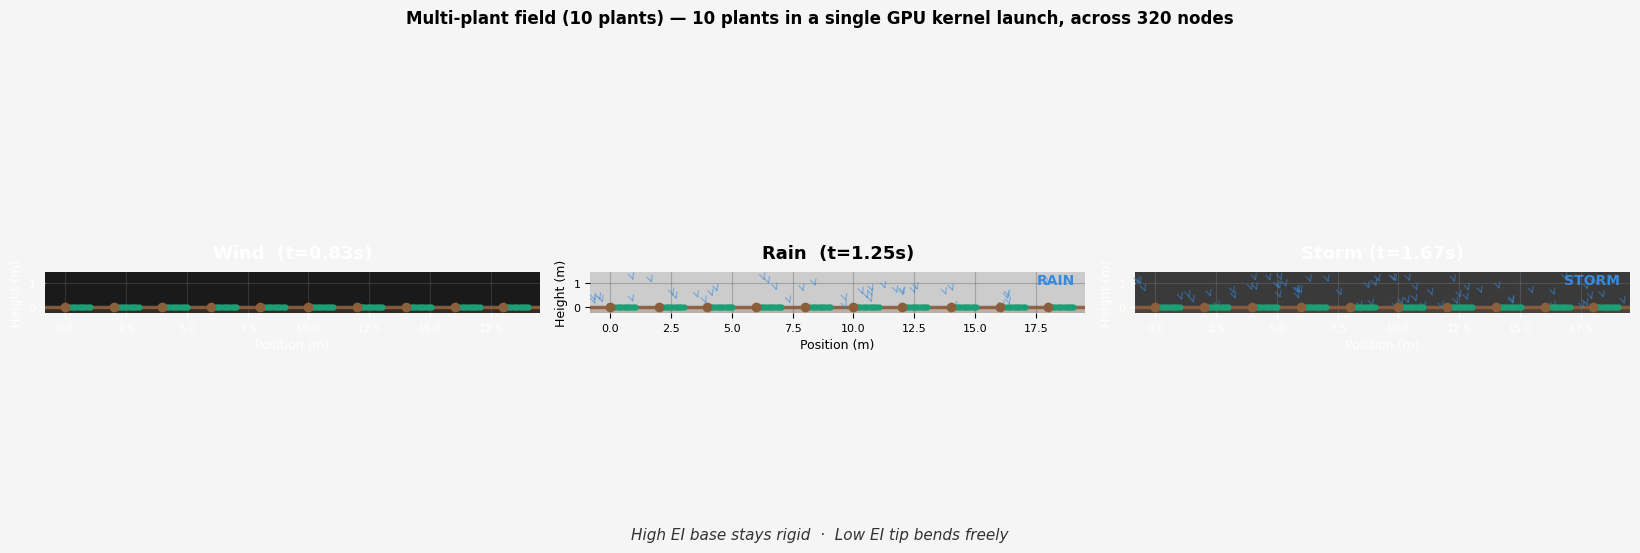

Saved field_10_plants.png

Done. GPU FPS at 10 plants: 4.6


In [5]:
import warp as wp
import numpy as np
import matplotlib.pyplot as plt
import time

wp.init()
print("Device:", wp.get_device())

# ══════════════════════════════════════════════════
#  CONFIG
# ══════════════════════════════════════════════════
STEM_NODES   = 12
STEM_HEIGHT  = 1.0
L0_STEM      = STEM_HEIGHT / (STEM_NODES - 1)
R_BASE       = 0.008
R_TIP        = 0.002
RHO_STEM     = 700.0
CD_STEM      = 1.0

LEAF_CONFIG  = [
    (3,  55, 3), (3, -55, 3),
    (6,  60, 4), (6, -60, 4),
    (9,  50, 3), (9, -50, 3),
]
L0_LEAF      = 0.06
R_LEAF       = 0.0015
A_LEAF_BLADE = 0.004
RHO_LEAF     = 500.0
CD_LEAF      = 2.0

G            = 9.81
RHO_AIR      = 1.225
RHO_WATER    = 1000.0
V_RAIN       = 9.0
RAIN_RATE    = 5.0e-5

SOIL_DEPTH   = 0.05
ROOT_DAMPING = 0.55
DT           = 1.0 / 60.0
SUBSTEPS     = 8
DAMPING      = 0.985

# Lower values allow real E*I gradient bending (base rigid, tip free)
BEND_BASE    = 0.55
BEND_TIP     = 0.003
BEND_LEAF    = 0.002
PBD_ITERS    = 10

TOTAL_FRAMES = 120
WIND_STRONG  = 12.0
WIND_CALM    = 0.5
RAIN_START   = 60       # Pushed after frame 50 snapshot
RAIN_LIGHT_END = 80
RAIN_END     = 100

def wind_speed(frame):
    if frame < RAIN_START:    return WIND_STRONG
    if frame < RAIN_END:      return WIND_STRONG * 1.2
    if frame < RAIN_END + 30: return 1.5
    return WIND_CALM

def rain_intensity(frame):
    if frame < RAIN_START:        return 0.0
    if frame <= RAIN_LIGHT_END:   return 1.0
    if frame <= RAIN_END:         return 2.0
    return 0.0


# ══════════════════════════════════════════════════
#  PLANT BUILDER
# ══════════════════════════════════════════════════
def stem_radius(i, n=STEM_NODES):
    t = i / (n - 1)
    return R_BASE + (R_TIP - R_BASE) * t

def area(r): return np.pi * r * r

def bend_stiffness_at_height(i):
    t = i / (STEM_NODES - 1)
    return BEND_TIP + (BEND_BASE - BEND_TIP) * (1.0 - t) ** 3

def build_single_plant(x_offset=0.0):
    pos, mass, is_root, is_leaf, front_area = [], [], [], [], []
    parents, children, L0_list, bend_k = [], [], [], []

    for i in range(STEM_NODES):
        y = i * L0_STEM
        pos.append([x_offset, y, 0.0])
        is_root.append(1 if i == 0 else 0)
        is_leaf.append(0)
        r = stem_radius(i)
        mass.append(max(RHO_STEM * area(r) * L0_STEM, 1e-5))
        front_area.append(2.0 * r * L0_STEM)
        if i > 0:
            parents.append(i - 1)
            children.append(i)
            L0_list.append(L0_STEM)
            bend_k.append(bend_stiffness_at_height(i))

    for (attach, angle_deg, n_seg) in LEAF_CONFIG:
        a = np.radians(angle_deg)
        dx, dy = np.sin(a) * L0_LEAF, np.cos(a) * L0_LEAF
        base = pos[attach]
        prev = attach
        for j in range(1, n_seg + 1):
            idx = len(pos)
            pos.append([base[0] + dx*j, base[1] + dy*j, 0.0])
            is_root.append(0); is_leaf.append(1)
            mass.append(RHO_LEAF * area(R_LEAF) * L0_LEAF)
            front_area.append(A_LEAF_BLADE)
            parents.append(prev); children.append(idx)
            L0_list.append(L0_LEAF); bend_k.append(BEND_LEAF)
            prev = idx

    n_nodes = len(pos)
    return dict(
        n_nodes=n_nodes,
        pos=np.asarray(pos, dtype=np.float32),
        mass=np.asarray(mass, dtype=np.float32),
        is_root=np.asarray(is_root, dtype=np.int32),
        is_leaf=np.asarray(is_leaf, dtype=np.int32),
        frontal_area=np.asarray(front_area, dtype=np.float32),
        parents=np.asarray(parents, dtype=np.int32),
        children=np.asarray(children, dtype=np.int32),
        L0=np.asarray(L0_list, dtype=np.float32),
        bend_k=np.asarray(bend_k, dtype=np.float32),
    )

def build_field(n_plants, spacing=2.0):
    all_pos, all_mass, all_root, all_leaf, all_area = [], [], [], [], []
    all_parents, all_children, all_L0, all_bend_k = [], [], [], []
    node_offset = 0

    for p in range(n_plants):
        plant = build_single_plant(x_offset=p * spacing)
        n = plant["n_nodes"]
        all_pos.append(plant["pos"])
        all_mass.append(plant["mass"])
        all_root.append(plant["is_root"])
        all_leaf.append(plant["is_leaf"])
        all_area.append(plant["frontal_area"])
        all_parents.append(plant["parents"]   + node_offset)
        all_children.append(plant["children"] + node_offset)
        all_L0.append(plant["L0"])
        all_bend_k.append(plant["bend_k"])
        node_offset += n

    pos_np = np.concatenate(all_pos, axis=0).astype(np.float32)
    return dict(
        n_plants=n_plants,
        spacing=spacing,
        n_nodes_per_plant=node_offset // n_plants,
        pos=pos_np,
        rest_pos=pos_np.copy(),
        vel=np.zeros_like(pos_np),
        mass=np.concatenate(all_mass).astype(np.float32),
        is_root=np.concatenate(all_root).astype(np.int32),
        is_leaf=np.concatenate(all_leaf).astype(np.int32),
        frontal_area=np.concatenate(all_area).astype(np.float32),
        parents=np.concatenate(all_parents).astype(np.int32),
        children=np.concatenate(all_children).astype(np.int32),
        L0=np.concatenate(all_L0).astype(np.float32),
        bend_k=np.concatenate(all_bend_k).astype(np.float32),
    )


# ══════════════════════════════════════════════════
#  GPU KERNEL
# ══════════════════════════════════════════════════
@wp.kernel
def k_apply_forces(positions:  wp.array(dtype=wp.vec3),
                   velocities: wp.array(dtype=wp.vec3),
                   mass:       wp.array(dtype=wp.float32),
                   area_arr:   wp.array(dtype=wp.float32),
                   is_root:    wp.array(dtype=wp.int32),
                   is_leaf:    wp.array(dtype=wp.int32),
                   wind_x:     float, rain_on: int,
                   rho_air:    float, rho_w:   float,
                   cd_stem:    float, cd_leaf:  float,
                   rain_rate:  float, v_rain:   float,
                   damping:    float, soil_damp: float,
                   soil_y:     float, dt:       float):
    i = wp.tid()
    if is_root[i] == 1:
        velocities[i] = wp.vec3(0.0, 0.0, 0.0)
        return

    m = mass[i]
    f = wp.vec3(0.0, -G * m, 0.0)

    v_rel = wp.vec3(wind_x, 0.0, 0.0) - velocities[i]
    speed = wp.length(v_rel)
    cd = cd_stem
    if is_leaf[i] == 1: cd = cd_leaf
    h_factor = positions[i][1] * 0.5 + 0.5
    f = f + v_rel * (0.5 * rho_air * cd * area_arr[i] * speed * h_factor)

    if rain_on == 1:
        rf = rho_w * rain_rate * v_rain * area_arr[i]
        if is_leaf[i] == 1: rf = rf * 25.0
        else:               rf = rf * 4.0
        f = f + wp.vec3(0.4 * rf, -rf, 0.0)

    a = f / m
    a_mag = wp.length(a)
    if a_mag > 500.0: a = a * (500.0 / a_mag)

    d = damping
    if positions[i][1] < soil_y: d = soil_damp

    velocities[i] = (velocities[i] + a * dt) * d
    positions[i]  =  positions[i]  + velocities[i] * dt

    if positions[i][1] < 0.0:
        positions[i]  = wp.vec3(positions[i][0], 0.0, positions[i][2])
        velocities[i] = wp.vec3(velocities[i][0], 0.0, velocities[i][2])


# ══════════════════════════════════════════════════
#  PBD SOLVER — TIP-TO-BASE + ANGLE DECOMPOSITION
# ══════════════════════════════════════════════════
def pbd_solve(pos, rest_pos, parents, children, L0, bend_k, is_root, n_iters=10):
    n_edges = len(parents)
    edge_parent = -np.ones(n_edges, dtype=np.int32)
    child_to_edge = -np.ones(len(pos), dtype=np.int32)

    for e in range(n_edges):
        child_to_edge[children[e]] = e
    for e in range(n_edges):
        p = parents[e]
        pe = child_to_edge[p]
        if pe != -1:
            edge_parent[e] = pe

    for _ in range(n_iters):
        # ── Distance constraints ──
        for e in range(n_edges):
            p, c = parents[e], children[e]
            diff = pos[c] - pos[p]
            dist = np.linalg.norm(diff)
            if dist > 1e-8:
                n_vec = diff / dist
                err = dist - L0[e]
                if is_root[p]:
                    pos[c] -= n_vec * err
                else:
                    pos[p] += n_vec * err * 0.5
                    pos[c] -= n_vec * err * 0.5

        # ── Bending: REVERSED (tip → base) ──
        for e in reversed(range(n_edges)):
            pe = edge_parent[e]
            if pe == -1: continue

            gp = parents[pe]
            gc = children[pe]
            c  = children[e]

            d1x = pos[gc, 0] - pos[gp, 0]
            d1y = pos[gc, 1] - pos[gp, 1]
            d2x = pos[c, 0]  - pos[gc, 0]
            d2y = pos[c, 1]  - pos[gc, 1]

            l1 = np.sqrt(d1x*d1x + d1y*d1y)
            l2 = np.sqrt(d2x*d2x + d2y*d2y)
            if l1 < 1e-8 or l2 < 1e-8: continue

            n1x = d1x / l1;  n1y = d1y / l1
            n2x = d2x / l2;  n2y = d2y / l2

            k = bend_k[e]

            # Decompose n2 into parallel + perpendicular to n1
            par = n1x*n2x + n1y*n2y
            perp_x = n2x - par * n1x
            perp_y = n2y - par * n1y

            # Shrink perpendicular component → straighten toward parent
            new_x = par * n1x + perp_x * (1.0 - k)
            new_y = par * n1y + perp_y * (1.0 - k)

            norm = np.sqrt(new_x*new_x + new_y*new_y)
            if norm < 1e-8: continue
            new_x /= norm;  new_y /= norm

            pos[c, 0] = pos[gc, 0] + new_x * l2
            pos[c, 1] = pos[gc, 1] + new_y * l2

    pos[:, 1] = np.maximum(pos[:, 1], 0.0)
    return pos


# ══════════════════════════════════════════════════
#  SIMULATION
# ══════════════════════════════════════════════════
def run_field(field, frames=TOTAL_FRAMES, snapshot_set=None):
    if snapshot_set is None:
        snapshot_set = {50, 75, 100}

    n = len(field["pos"])
    pos_np = field["pos"].copy()
    vel_np = field["vel"].copy()

    pos_gpu  = wp.array(pos_np, dtype=wp.vec3,   device="cuda")
    vel_gpu  = wp.array(vel_np, dtype=wp.vec3,   device="cuda")
    mass_gpu = wp.array(field["mass"],        dtype=wp.float32, device="cuda")
    area_gpu = wp.array(field["frontal_area"],dtype=wp.float32, device="cuda")
    root_gpu = wp.array(field["is_root"],     dtype=wp.int32,   device="cuda")
    leaf_gpu = wp.array(field["is_leaf"],     dtype=wp.int32,   device="cuda")

    sub_dt = DT / SUBSTEPS
    snapshots = {}
    t_start = time.perf_counter()
    roots = np.where(field["is_root"] == 1)[0]

    for frame in range(frames):
        w       = wind_speed(frame)
        rain_on = 1 if rain_intensity(frame) > 0.0 else 0

        for _ in range(SUBSTEPS):
            wp.launch(k_apply_forces, dim=n,
                      inputs=[pos_gpu, vel_gpu, mass_gpu, area_gpu,
                              root_gpu, leaf_gpu, w, rain_on,
                              RHO_AIR, RHO_WATER, CD_STEM, CD_LEAF,
                              RAIN_RATE, V_RAIN,
                              DAMPING, ROOT_DAMPING, SOIL_DEPTH, sub_dt])

            pos_np = pos_gpu.numpy().copy()
            vel_np = vel_gpu.numpy().copy()

            if not np.all(np.isfinite(pos_np)):
                pos_np = field["rest_pos"].copy()
                vel_np = np.zeros_like(pos_np)

            for r_idx in roots:
                pos_np[r_idx] = field["rest_pos"][r_idx]
                vel_np[r_idx] = [0.0, 0.0, 0.0]

            pos_np = pbd_solve(pos_np, field["rest_pos"],
                               field["parents"], field["children"],
                               field["L0"], field["bend_k"],
                               field["is_root"], n_iters=PBD_ITERS)

            pos_gpu = wp.array(pos_np, dtype=wp.vec3, device="cuda")
            vel_gpu = wp.array(vel_np, dtype=wp.vec3, device="cuda")

        if frame in snapshot_set:
            snapshots[frame] = pos_np.copy()

    elapsed = time.perf_counter() - t_start
    fps = frames / elapsed
    return snapshots, fps


# ══════════════════════════════════════════════════
#  BENCHMARK
# ══════════════════════════════════════════════════
def benchmark():
    print("\n" + "="*54)
    print(f"{'Plants':>8}  {'Nodes':>6}  {'GPU fps':>9}  {'ms/frame':>10}")
    print("="*54)
    for n_plants in [1, 5, 10, 25, 50]:
        field = build_field(n_plants)
        _, fps = run_field(field, frames=60, snapshot_set=set())
        ms = 1000.0 / fps
        print(f"{n_plants:>8}  {len(field['pos']):>6}  {fps:>9.1f}  {ms:>10.2f}")
    print("="*54)


# ══════════════════════════════════════════════════
#  PLOT
# ══════════════════════════════════════════════════
def plot_field(snapshots, field, n_plants):
    frame_labels = {
        50:  "Wind  (t=0.83s)",
        75:  "Rain  (t=1.25s)",
        100: "Storm (t=1.67s)"
    }
    bg_colors  = {50: '#1A1A1A', 75: '#CCCCCC', 100: '#3A3A3A'}
    txt_colors = {50: 'white',   75: 'black',   100: 'white'}
    grid_alpha = {50: 0.12,     75: 0.20,      100: 0.12}

    frames   = sorted(snapshots.keys())
    spacing  = field["spacing"]
    nodes_pp = field["n_nodes_per_plant"]

    x_min = -0.8
    x_max = (n_plants - 1) * spacing + 1.5

    fig, axes = plt.subplots(1, len(frames),
                             figsize=(5.5 * len(frames), 5.5),
                             facecolor='#F5F5F5')

    stem_color = '#1D9E75'
    leaf_color = '#5DCAA5'
    rain_col   = '#378ADD'

    for col, f in enumerate(frames):
        ax   = axes[col]
        snap = snapshots[f]
        ri   = rain_intensity(f)

        ax.set_facecolor(bg_colors[f])
        tc = txt_colors[f]

        # Ground
        ax.axhspan(-0.3, 0.0, color='#8B5E3C', alpha=0.25)
        ax.axhline(y=0, color='#8B5E3C', linewidth=2.5, alpha=0.9)

        # Rain streaks
        if ri > 0:
            rng = np.random.default_rng(seed=col * 17)
            n_drops = int(15 + ri * 25)
            for _ in range(n_drops):
                rx = rng.uniform(x_min, x_max)
                ry = rng.uniform(0.1, 1.3)
                ax.annotate('',
                    xy=(rx + 0.06, ry - 0.18), xytext=(rx, ry),
                    arrowprops=dict(arrowstyle='->', color=rain_col,
                                    lw=0.9, alpha=0.5))
            label = 'RAIN' if ri < 1.5 else 'STORM'
            ax.text(0.98, 0.97, label, transform=ax.transAxes,
                    fontsize=10, color=rain_col,
                    ha='right', va='top', fontweight='bold')

        # Draw plants
        for p in range(n_plants):
            start = p * nodes_pp

            sx = snap[start:start + STEM_NODES, 0]
            sy = snap[start:start + STEM_NODES, 1]
            ax.plot(sx, sy, 'o-', color=stem_color,
                    linewidth=2.2, markersize=3.5, zorder=3)

            cursor = start + STEM_NODES
            for (attach, ang, n_seg) in LEAF_CONFIG:
                leaf_idx = [start + attach] + list(
                    range(cursor, cursor + n_seg))
                ax.plot(snap[leaf_idx, 0], snap[leaf_idx, 1],
                        'o-', color=leaf_color,
                        linewidth=1.2, markersize=2.5,
                        alpha=0.85, zorder=2)
                cursor += n_seg

            root_x = field["rest_pos"][start, 0]
            ax.plot(root_x, 0, 'o', color='#8B5E3C', markersize=6, zorder=5)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(-0.25, 1.45)
        ax.set_aspect('equal', adjustable='box')

        ax.set_title(frame_labels.get(f, f"frame {f}"),
                     fontsize=13, color=tc, fontweight='bold', pad=10)
        ax.set_xlabel("Position (m)", fontsize=9, color=tc)
        ax.set_ylabel("Height (m)",   fontsize=9, color=tc)
        ax.tick_params(axis='both', colors=tc, labelsize=8)
        ax.grid(True, alpha=grid_alpha[f], color=tc)
        for spine in ax.spines.values():
            spine.set_visible(False)

    fig.text(0.5, 0.01,
             "High EI base stays rigid  ·  Low EI tip bends freely",
             ha='center', va='bottom', fontsize=11,
             color='#333333', style='italic')
    fig.suptitle(
        f"Multi-plant field ({n_plants} plants) — "
        f"{n_plants} plants in a single GPU kernel launch, across {len(field['pos'])} nodes",
        fontsize=12, y=0.98, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 0.95])
    fname = f"field_{n_plants}_plants.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {fname}")


# ══════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════
print("\nRunning benchmark...")
benchmark()

print("\nRendering 10-plant field...")
field_10    = build_field(n_plants=10)
snaps_10, fps_10 = run_field(field_10, snapshot_set={50, 75, 100})
plot_field(snaps_10, field_10, n_plants=10)

print(f"\nDone. GPU FPS at 10 plants: {fps_10:.1f}")